### Simple Linear Regression to predict the salary based on the years of experience

#### Step 1: Import all the necessary libraries

In [1069]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   sklearn.model_selection   import   train_test_split
from   sklearn.preprocessing     import   StandardScaler
from   sklearn.linear_model      import   LinearRegression
from   sklearn.metrics           import   accuracy_score, classification_report, confusion_matrix

#### Step 2 : Load the dataset

In [1070]:
df = pd.read_csv('experience_salary_dataset.csv')

In [1071]:
df

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.5,48266
7,2.9,56642
8,3.0,60150
9,3.2,54445


### OBSERVATIONS:

1.  The above dataset is a experience salary dataset.

2.  It has two columns . One is :

    (a.)  Experience Years	--------------->  It specifies the years of experience that the employee has worked.

    (b.)  salary            --------------->  It specifies the salary of an employee.

### Step 3 : Perform the Data Exploration

In [1072]:
### get the first five rows of the dataframe

df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


In [1073]:
### get the last five rows of the dataframe

df.tail()

,Experience Years,Salary
35,9.0,105582
36,9.5,116969
37,9.6,112635
38,10.3,122391
39,10.5,121872


In [1074]:
### get the columns used in the dataframe

df.columns

Index(['Experience Years', 'Salary'], dtype='object')

In [1075]:
### get the information about the columns used in the dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


In [1076]:
### get the total records used in the dataframe

print("Total length of the records used in the dataframe:", len(df))

Total length of the records used in the dataframe: 40


In [1077]:
#### get the shape of the dataset

print("Shape of the dataframe is:", df.shape)

Shape of the dataframe is: (40, 2)


#### OBSERVATIONS:

1.  The dataset named 'experience_salary_dataset' has 40 rows and 2 columns.

In [1078]:
### get the statistical summary about the dataset

df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


#### OBSERVATIONS:

1. The above dataframe contains the statistical information about the numerical columns used in the dataframe.

#### Step 4: Perform Data Preprocessing

In [1079]:
### reset the index

df.reset_index(drop = True, inplace = True)

In [1080]:
df

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.5,48266
7,2.9,56642
8,3.0,60150
9,3.2,54445


#### OBSERVATIONS:

1.  It resets the dataframe index by removing the index as the column.

In [1081]:
#### Check for any NULL Values used in the dataframe

df.isnull().sum()

Experience Years    0
Salary              0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values used in the dataframe.

In [1082]:
#### Check for the duplicate reocrds used in the dataframe

df[df.duplicated()]

,Experience Years,Salary


#### OBSERVATIONS:

1. There are no duplicate records used in the dataframe.

In [1083]:
### get the correlation between the features used in the dataframe

df.corr()

,Experience Years,Salary
Experience Years,1.000000,0.977692
Salary,0.977692,1.000000


### OBSERVATIONS:

1. The above dataframe depicts about the correlation between the features used in the dataframe.

2. There is a 

        (a.)    positive correlation of 1 between the (years of exp) and (years of exp)

        (b.)    positive correlation of 0.97 between the (years of exp) and (Salary) which means the years of exp is highly related with respect to salary.

<Axes: >

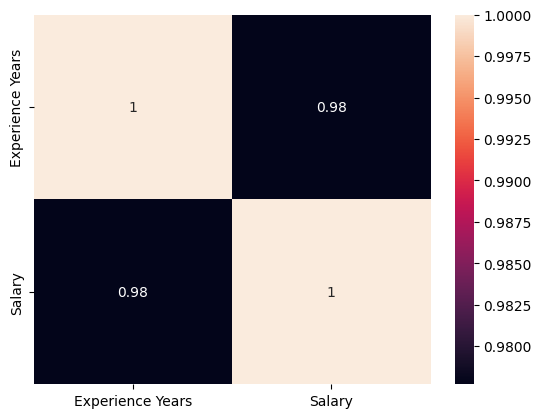

In [1084]:
### depict the above correlation matrix in graphical form

sns.heatmap(df.corr(), annot=True)

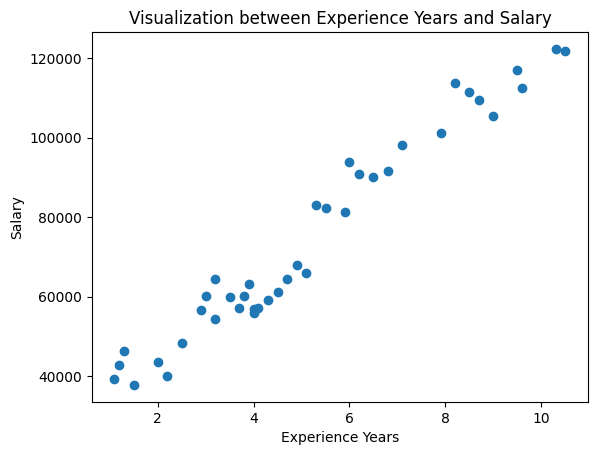

In [1085]:
### Perform the Visualization between 'Experience Years' and 'Salary'

plt.scatter(df['Experience Years'], df['Salary'])
plt.title('Visualization between Experience Years and Salary')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the visualization between the Experience Years and Salary.

2.  With the increase in the years of experience, Salary of the employee also increases.

#### Step 5: Divide the dataset into independent and dependent features

In [1086]:
#### Independent features

X = df[['Experience Years']]

In [1087]:
print(X)

    Experience Years
0                1.1
1                1.2
2                1.3
3                1.5
4                2.0
5                2.2
6                2.5
7                2.9
8                3.0
9                3.2
10               3.2
11               3.5
12               3.7
13               3.8
14               3.9
15               4.0
16               4.0
17               4.1
18               4.3
19               4.5
20               4.7
21               4.9
22               5.1
23               5.3
24               5.5
25               5.9
26               6.0
27               6.2
28               6.5
29               6.8
30               7.1
31               7.9
32               8.2
33               8.5
34               8.7
35               9.0
36               9.5
37               9.6
38              10.3
39              10.5


In [1088]:
#### Dependent features

Y = df['Salary']

In [1089]:
print(Y)

0      39343
1      42774
2      46205
3      37731
4      43525
5      39891
6      48266
7      56642
8      60150
9      54445
10     64445
11     60000
12     57189
13     60200
14     63218
15     55794
16     56957
17     57081
18     59095
19     61111
20     64500
21     67938
22     66029
23     83088
24     82200
25     81363
26     93940
27     91000
28     90000
29     91738
30     98273
31    101302
32    113812
33    111620
34    109431
35    105582
36    116969
37    112635
38    122391
39    121872
Name: Salary, dtype: int64


#### OBSERVATIONS:

1.  The dataset is divided into the independent and dependent features.

#### Step 6: Divide the dataset into training and testing data

In [1090]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [1091]:
X_train

,Experience Years
39,10.5
6,2.5
25,5.9
9,3.2
13,3.8
31,7.9
34,8.7
8,3.0
17,4.1
24,5.5


In [1092]:
X_test

,Experience Years
19,4.5
16,4.0
15,4.0
26,6.0
4,2.0
12,3.7
37,9.6
27,6.2


In [1093]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (32, 1)
Shape of the input testing  data is: (8, 1)


In [1094]:
Y_train

39    121872
6      48266
25     81363
9      54445
13     60200
31    101302
34    109431
8      60150
17     57081
24     82200
0      39343
33    111620
5      39891
11     60000
1      42774
29     91738
21     67938
2      46205
30     98273
36    116969
3      37731
35    105582
23     83088
32    113812
10     64445
22     66029
18     59095
20     64500
7      56642
14     63218
28     90000
38    122391
Name: Salary, dtype: int64

In [1095]:
Y_test

19     61111
16     56957
15     55794
26     93940
4      43525
12     57189
37    112635
27     91000
Name: Salary, dtype: int64

In [1096]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (32,)
Shape of the output testing  data is: (8,)


#### Step 7: Train the Simple Linear Regression Model

In [1097]:
from sklearn.linear_model import LinearRegression

#### Create an object for SLR

model = LinearRegression()

### use the training data, to train the model

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### OBSERVATIONS:

1.  The model for Linear Regression is trained with the help of the training data.

#### Step 8: Predict the Model

In [1098]:
Y_pred = model.predict(X_test)   ### use the input testing data

In [1099]:
Y_pred

array([ 69052.39090243,  64348.37526617,  64348.37526617,  83164.43781119,
        45532.31272116,  61525.96588442, 117033.35039221,  85046.04406569])

#### Step 9 : Compare the Actual vs Predicted results in a dataframe

In [1100]:
results = pd.DataFrame({
    'Actual Results'       :          Y_test                   ,
    'Predicted Results'    :          Y_pred                   ,
    'Error'                :          (Y_test - Y_pred)
})

In [1101]:
results

,Actual Results,Predicted Results,Error
19,61111,69052.390902,-7941.390902
16,56957,64348.375266,-7391.375266
15,55794,64348.375266,-8554.375266
26,93940,83164.437811,10775.562189
4,43525,45532.312721,-2007.312721
12,57189,61525.965884,-4336.965884
37,112635,117033.350392,-4398.350392
27,91000,85046.044066,5953.955934


#### OBSERVATIONS:

1. We have obtained the dataframe where we have all the Actual Results vs the Predicted Results

2. Then we have stored all the difference between the Actual Results and the Predicted Results in a column called 'Error'.

#### Step 10: Perform the Model Evaluation

In [1102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)


mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)

rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)

r2score = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2score)

Mean Squared Error of the model is: 48077731.16919359
Mean Absolute Error of the model is: 6419.911069460598
Root Mean Squared Error of the model is: 6933.810724932834
R2 Score of the model is: 0.9068577573647874


#### OBSERVATIONS:

1. The R2 Score of the model is 0.9 which is very high and accurate. So the model is completely fine.

#### Step 11: Save the Model

In [1103]:
import joblib

In [1104]:
#### Save the model

joblib.dump(model,"salary_model.pkl")

['salary_model.pkl']

#### OBSERVATIONS:

1.  The Simple Linear Regression model has been dumped into a pkl file named 'salary_model'.

#### Step 12: Streamlit Development

In [1105]:
import streamlit as st
import joblib
import numpy     as np
import pandas    as pd

In [ ]:
#### Load the model

model = joblib.load("salary_model.pkl")


#### Write the title of the model using Streamlit
st.title("Salary Prediction App")